# Gaussian Mixture Models

### Clustering that admits it is uncertain

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How a mixture model differs from k-means, what expectation-maximisation does, what the covariance types buy you, and how BIC picks the number of components |
| **You should already know** | [k-Means](../01-k-means/) |
| **Dataset** | UCI Dry Bean, plus stretched blobs that broke k-means |
| **Runtime** | About a minute on a laptop CPU |
| **Next** | [05-06 Anomaly detection](../06-anomaly-detection/) |

---

## 1. The idea

[k-means](../01-k-means/) had two limits. Every cluster is a sphere, and every
point belongs to exactly one of them.

A Gaussian mixture relaxes both. It assumes the data was generated by $k$ normal
distributions, each with its **own centre and its own shape**, and it reports for
every point the **probability** it came from each one.

$$p(x) = \sum_{i=1}^{k} \pi_i \, \mathcal{N}(x \mid \mu_i, \Sigma_i)$$

Three things per component: how common it is ($\pi_i$), where it sits ($\mu_i$),
and what shape it has ($\Sigma_i$). That covariance matrix is the whole upgrade:
it lets a cluster be a stretched, tilted ellipse instead of a ball.

k-means is the special case where every $\Sigma_i$ is the identity and every point
is assigned with probability 1. **k-means is a hard, spherical mixture model.**

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. Expectation-maximisation

The fitting problem is circular. If you knew which component produced each point,
you could compute the components. If you knew the components, you could work out
which produced each point. You know neither.

EM breaks the circle by guessing and alternating:

**E-step.** Given the current components, compute the probability each point came
from each one. These are the *responsibilities*.

**M-step.** Given those probabilities, recompute each component's centre, shape
and weight, as a weighted average over all points, weighted by responsibility.

Each round provably increases the likelihood, so it converges. It converges to a
*local* optimum, which is why `n_init` matters exactly as it did for k-means.

Notice the shape of the algorithm is identical to Lloyd's: assign, update,
repeat. The only change is that assignment is soft.

## 3. The shapes k-means could not see

k-means  adjusted Rand : 0.589
GMM      adjusted Rand : 0.796

points assigned with less than 80% confidence: 17.3%


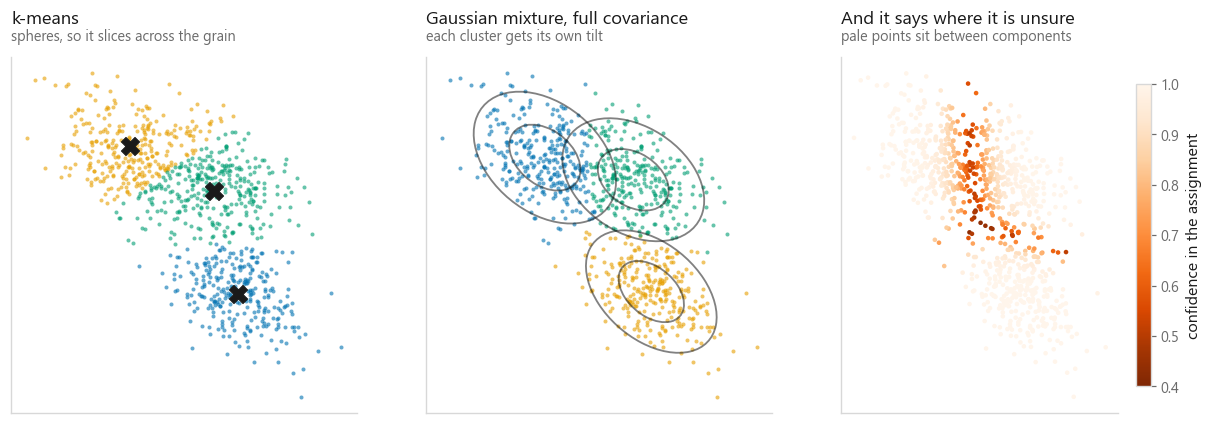

In [2]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
from matplotlib.patches import Ellipse

rng = np.random.default_rng(SEED)
blobs = make_blobs(n_samples=900, centers=3, cluster_std=1.0, random_state=SEED)[0]
stretched = blobs @ np.array([[0.7, -0.7], [0.15, 0.9]])


def draw_ellipses(ax, model):
    for i in range(model.n_components):
        covariance = model.covariances_[i]
        values, vectors = np.linalg.eigh(covariance)
        angle = np.degrees(np.arctan2(vectors[1, -1], vectors[0, -1]))
        width, height = 2 * np.sqrt(values[::-1])
        for scale in (1, 2):
            ax.add_patch(Ellipse(model.means_[i], scale * width, scale * height, angle=angle,
                                 facecolor="none", edgecolor=style.INK, lw=1.2, alpha=0.55))


fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.2), sharex=True, sharey=True)

km = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(stretched)
for c in range(3):
    sel = km.labels_ == c
    axes[0].scatter(stretched[sel, 0], stretched[sel, 1], s=7, alpha=0.6,
                    c=style.PALETTE[c], linewidths=0)
axes[0].scatter(*km.cluster_centers_.T, s=140, marker="X", c=style.INK, zorder=5)
style.title(axes[0], "k-means", "spheres, so it slices across the grain")

gmm = GaussianMixture(n_components=3, covariance_type="full", n_init=10,
                      random_state=SEED).fit(stretched)
labels = gmm.predict(stretched)
for c in range(3):
    sel = labels == c
    axes[1].scatter(stretched[sel, 0], stretched[sel, 1], s=7, alpha=0.6,
                    c=style.PALETTE[c], linewidths=0)
draw_ellipses(axes[1], gmm)
style.title(axes[1], "Gaussian mixture, full covariance", "each cluster gets its own tilt")

confidence = gmm.predict_proba(stretched).max(axis=1)
scatter = axes[2].scatter(stretched[:, 0], stretched[:, 1], s=9, c=confidence,
                          cmap="Oranges_r", vmin=0.4, vmax=1.0, linewidths=0)
fig.colorbar(scatter, ax=axes[2], shrink=0.85, label="confidence in the assignment")
style.title(axes[2], "And it says where it is unsure", "pale points sit between components")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
style.save(fig, FIG / "fig-01-shapes.png")

from sklearn.metrics import adjusted_rand_score
true_labels = make_blobs(n_samples=900, centers=3, cluster_std=1.0, random_state=SEED)[1]
print(f"k-means  adjusted Rand : {adjusted_rand_score(true_labels, km.labels_):.3f}")
print(f"GMM      adjusted Rand : {adjusted_rand_score(true_labels, labels):.3f}")
print(f"\npoints assigned with less than 80% confidence: {(confidence < 0.8).mean():.1%}")

The third panel is the thing k-means genuinely cannot do. Points near a boundary
come out pale, meaning the model is telling you it does not know. k-means assigns
every point with equal, unearned certainty.

## 4. The covariance types

`covariance_type` is the dial that decides how much shape each cluster may have,
and it trades flexibility against the number of parameters to estimate.

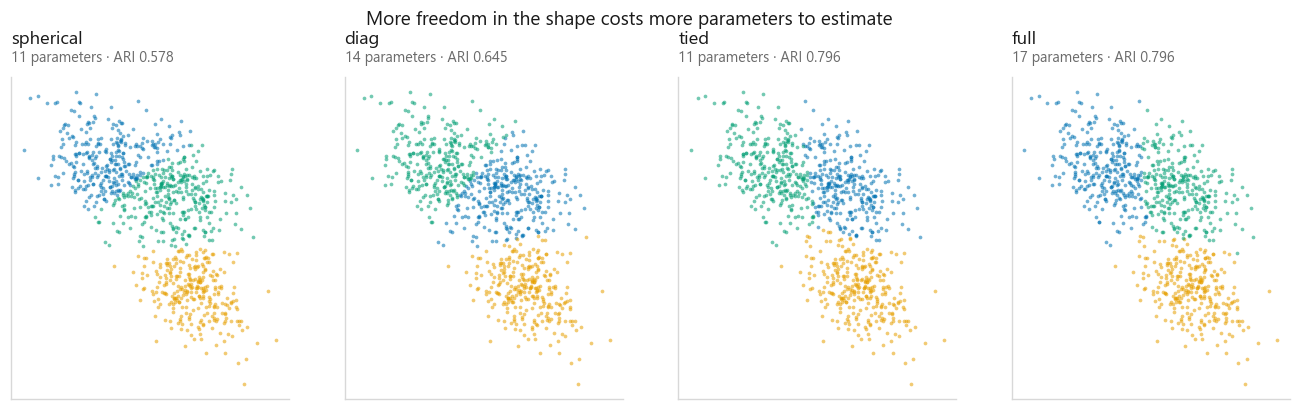

In [3]:
types = ["spherical", "diag", "tied", "full"]
fig, axes = plt.subplots(1, 4, figsize=(15.0, 3.8), sharex=True, sharey=True)

for ax, kind in zip(axes, types):
    model = GaussianMixture(n_components=3, covariance_type=kind, n_init=10,
                            random_state=SEED).fit(stretched)
    assignment = model.predict(stretched)
    for c in range(3):
        sel = assignment == c
        ax.scatter(stretched[sel, 0], stretched[sel, 1], s=6, alpha=0.55,
                   c=style.PALETTE[c], linewidths=0)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    style.title(ax, kind, f"{model._n_parameters()} parameters · "
                          f"ARI {adjusted_rand_score(true_labels, assignment):.3f}")

fig.suptitle("More freedom in the shape costs more parameters to estimate",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-covariance-types.png")

**spherical** is k-means with soft assignment, one variance per cluster.
**diag** allows axis-aligned ellipses. **tied** gives every cluster the same
shape, sharing one covariance matrix. **full** lets every cluster tilt freely,
and costs the most parameters.

Use `full` when you have plenty of data, and step down when you do not: with
few points per cluster, estimating a full covariance matrix is how a mixture
model overfits.

## 5. Choosing k with a criterion instead of an elbow

[k-means](../01-k-means/) had no principled way to choose k: the elbow was a
judgement call and the silhouette disagreed with the truth. A mixture model is a
proper probability model, so it can be scored by likelihood, and **BIC** penalises
that likelihood by the number of parameters used to earn it.

$$\text{BIC} = -2\log L + p \log n$$

Lower is better. Unlike inertia, it does not automatically improve as k rises,
because every extra component costs $p \log n$.

              ARI                BIC             
covariance   diag   full        diag         full
k                                                
2           0.275  0.297  441945.255  -697488.185
3           0.400  0.379  384933.218  -780145.415
4           0.440  0.421  328997.422  -853217.080
5           0.575  0.519  284816.860  -910264.843
6           0.705  0.696  231386.361  -954128.138
7           0.639  0.682  206960.652  -996969.784
8           0.656  0.575  188841.732 -1016426.910
9           0.609  0.602  175358.468 -1036254.413
10          0.558  0.575  159968.451 -1048519.959
11          0.539  0.515  151809.069 -1056048.779
12          0.496  0.494  145129.989 -1074463.544

BIC's choice     : k = 12, full covariance
true varieties   : 7



adjusted Rand at k=7: GMM 0.682 (full), k-means 0.669


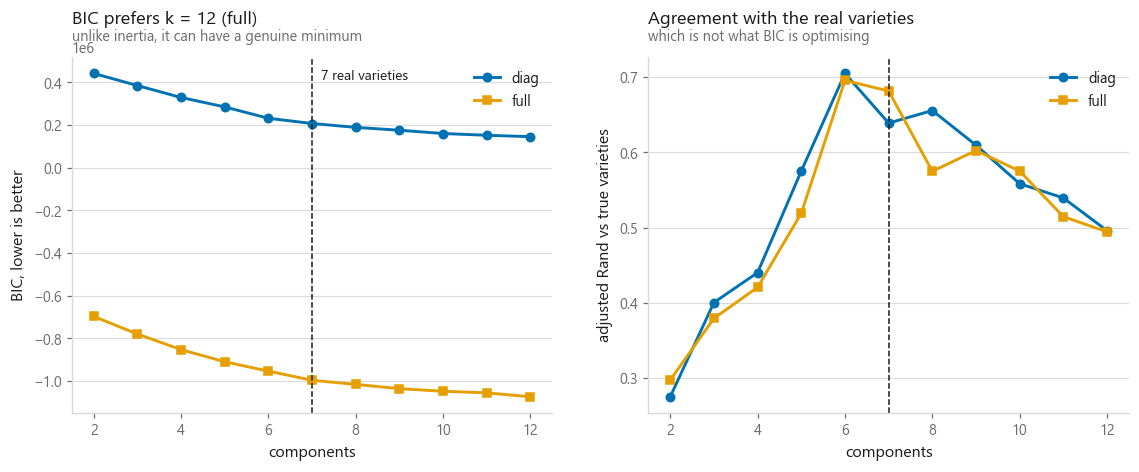

In [4]:
X_bean, y_bean = datasets.dry_bean()
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_bean)

records = []
for k in range(2, 13):
    for kind in ["diag", "full"]:
        model = GaussianMixture(n_components=k, covariance_type=kind, n_init=3,
                                random_state=SEED).fit(X_scaled)
        records.append({"k": k, "covariance": kind, "BIC": model.bic(X_scaled),
                        "ARI": adjusted_rand_score(y_bean, model.predict(X_scaled))})
sweep = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))
for i, kind in enumerate(["diag", "full"]):
    subset = sweep[sweep.covariance == kind]
    axes[0].plot(subset["k"], subset["BIC"], marker=style.MARKERS[i],
                 color=style.PALETTE[i], label=kind)
    axes[1].plot(subset["k"], subset["ARI"], marker=style.MARKERS[i],
                 color=style.PALETTE[i], label=kind)

best = sweep.loc[sweep.BIC.idxmin()]
axes[0].axvline(7, color=style.INK, ls="--", lw=1)
axes[0].annotate("7 real varieties", xy=(7, sweep.BIC.max()), xytext=(6, -4),
                 textcoords="offset points", fontsize=9, color=style.INK)
axes[0].set_xlabel("components"); axes[0].set_ylabel("BIC, lower is better")
axes[0].legend()
style.title(axes[0], f"BIC prefers k = {int(best.k)} ({best.covariance})",
            "unlike inertia, it can have a genuine minimum")

axes[1].axvline(7, color=style.INK, ls="--", lw=1)
axes[1].set_xlabel("components"); axes[1].set_ylabel("adjusted Rand vs true varieties")
axes[1].legend()
style.title(axes[1], "Agreement with the real varieties", "which is not what BIC is optimising")

style.save(fig, FIG / "fig-03-choosing-k.png")

print(sweep.pivot_table(index="k", columns="covariance", values=["BIC", "ARI"]).round(3).to_string())
print(f"\nBIC's choice     : k = {int(best.k)}, {best.covariance} covariance")
print(f"true varieties   : 7")
kmeans_ari = adjusted_rand_score(y_bean, KMeans(7, n_init=10, random_state=SEED).fit_predict(X_scaled))
gmm7 = sweep[(sweep.k == 7)].sort_values("ARI").iloc[-1]
print(f"\nadjusted Rand at k=7: GMM {gmm7.ARI:.3f} ({gmm7.covariance}), k-means {kmeans_ari:.3f}")

**BIC did not pick 7.** It preferred twelve components with full covariance, and
that is worth being straight about, because it is the usual outcome and the
textbook rarely says so.

BIC answers "how many Gaussians describe this density best", which is a different
question from "how many varieties of bean are there". Seven real varieties, each
slightly non-Gaussian in shape, are described better by twelve Gaussians than by
seven, so BIC buys extra components to patch the shape mismatch, and the
likelihood gain outweighs the parameter charge.

BIC is a genuine improvement on the [k-means elbow](../01-k-means/) because it
*can* have a real minimum rather than sliding forever. It is still answering a
statistical question, not your question. Use it to narrow the range, then look at
the clusters.

At the true k of 7 the mixture does beat k-means on agreement with the real
varieties, which is the comparison that was actually asked.

## Cheat sheet

| | |
|---|---|
| **Use it when** | Clusters are elliptical or differently shaped; you want probabilities rather than hard labels; you want a defensible way to narrow down k |
| **Avoid it when** | Clusters are non-convex: crescents and rings are still out of reach, use [DBSCAN](../04-dbscan-and-hdbscan/); you have very few points per cluster |
| **Scaling needed** | Yes, for the same reason as k-means |
| **Main dials** | `n_components`, `covariance_type`, `n_init` (keep it above 1, EM finds local optima) |
| **Choosing k** | BIC or AIC. Both can have a real minimum, which inertia cannot |
| **Bonus use** | `score_samples` gives a density, so a fitted mixture doubles as an [anomaly detector](../06-anomaly-detection/) |

## What to remember

1. A mixture model gives every cluster its own shape and every point a probability.
2. k-means is the hard, spherical special case.
3. EM alternates soft assignment and weighted re-estimation, and converges to a
   local optimum.
4. `covariance_type` trades shape freedom against parameters to estimate.
5. BIC has a real minimum, which inertia never does, but it picked 12 when the
   truth was 7, because it asks how many Gaussians fit the density, not how many
   groups you care about. Narrow the range with it, then look.
6. Pale points in the confidence plot are the model admitting uncertainty, which
   k-means never does.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [05-06 Anomaly detection](../06-anomaly-detection/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#GaussianMixture` `#GMM` `#Clustering` `#UnsupervisedLearning`
`#ExpectationMaximization` `#Python` `#ScikitLearn` `#MLTutorial` `#BIC`